# **Exploratory Data Analysis**

Peformed structured exploratory analysis to understand feature type and distribution, class imbalance, missing values and initial signal strength by checking correlation between attributes in the credit default dataset.

In [1]:
import pandas as pd
import numpy as np
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Data loading**

In [2]:
application_train = pd.read_csv('/content/drive/MyDrive/Credit_default_model_dataset/HC_application_train.csv')
application_train.head(5)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


**Checking data type of non null values in every column of the dataset**

In [3]:
application_train.info(verbose=True,show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 122 columns):
 #    Column                        Non-Null Count   Dtype  
---   ------                        --------------   -----  
 0    SK_ID_CURR                    307511 non-null  int64  
 1    TARGET                        307511 non-null  int64  
 2    NAME_CONTRACT_TYPE            307511 non-null  object 
 3    CODE_GENDER                   307511 non-null  object 
 4    FLAG_OWN_CAR                  307511 non-null  object 
 5    FLAG_OWN_REALTY               307511 non-null  object 
 6    CNT_CHILDREN                  307511 non-null  int64  
 7    AMT_INCOME_TOTAL              307511 non-null  float64
 8    AMT_CREDIT                    307511 non-null  float64
 9    AMT_ANNUITY                   307499 non-null  float64
 10   AMT_GOODS_PRICE               307233 non-null  float64
 11   NAME_TYPE_SUITE               306219 non-null  object 
 12   NAME_INCOME_TYPE            

**Checking cardinality in categorical columns**

In [4]:
obj_cols = application_train.select_dtypes(include='object').columns
obj_cols

Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE',
       'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'],
      dtype='object')

In [5]:
application_train[obj_cols].nunique(dropna=True)

,0
NAME_CONTRACT_TYPE,2
CODE_GENDER,3
FLAG_OWN_CAR,2
FLAG_OWN_REALTY,2
NAME_TYPE_SUITE,7
NAME_INCOME_TYPE,8
NAME_EDUCATION_TYPE,5
NAME_FAMILY_STATUS,6
NAME_HOUSING_TYPE,6
OCCUPATION_TYPE,18


**Checking unique values in relatively high cardinality columns**

In [6]:
application_train['ORGANIZATION_TYPE'].value_counts()

,count
ORGANIZATION_TYPE,
Business Entity Type 3,67992
XNA,55374
Self-employed,38412
Other,16683
Medicine,11193
Business Entity Type 2,10553
Government,10404
School,8893
Trade: type 7,7831


In [7]:
application_train['OCCUPATION_TYPE'].value_counts()

,count
OCCUPATION_TYPE,
Laborers,55186
Sales staff,32102
Core staff,27570
Managers,21371
Drivers,18603
High skill tech staff,11380
Accountants,9813
Medicine staff,8537
Security staff,6721


**Checking numerical columns**

In [8]:
num_cols = application_train.select_dtypes(include=['int64','float64']).columns

In [9]:
application_train.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


**Target variable: checking class imbalance**

In [10]:
application_train['TARGET'].value_counts(normalize=True)

,proportion
TARGET,
0,0.919271
1,0.080729


**Correlation strength between the target variable and the different attributes**

In [11]:
target_corr = application_train[num_cols].corr()['TARGET']
target_corr.abs().sort_values(ascending=False).head(10)

,TARGET
TARGET,1.000000
EXT_SOURCE_3,0.178919
EXT_SOURCE_2,0.160472
EXT_SOURCE_1,0.155317
DAYS_BIRTH,0.078239
REGION_RATING_CLIENT_W_CITY,0.060893
REGION_RATING_CLIENT,0.058899
DAYS_LAST_PHONE_CHANGE,0.055218
DAYS_ID_PUBLISH,0.051457
REG_CITY_NOT_WORK_CITY,0.050994


**For some of the most highly correlated attributes, checking how differently the attribute behaves for the two target classses.**

<Axes: xlabel='TARGET', ylabel='EXT_SOURCE_3'>

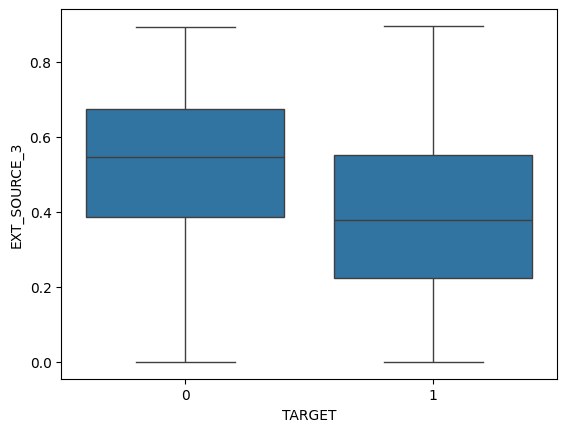

In [12]:
sns.boxplot(x=application_train['TARGET'],y=application_train['EXT_SOURCE_3'])

<Axes: xlabel='TARGET', ylabel='EXT_SOURCE_1'>

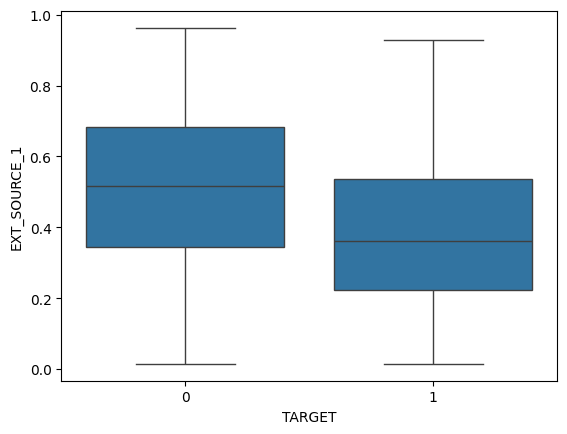

In [13]:
sns.boxplot(x=application_train['TARGET'],y=application_train['EXT_SOURCE_1'])

<Axes: xlabel='TARGET', ylabel='DAYS_BIRTH'>

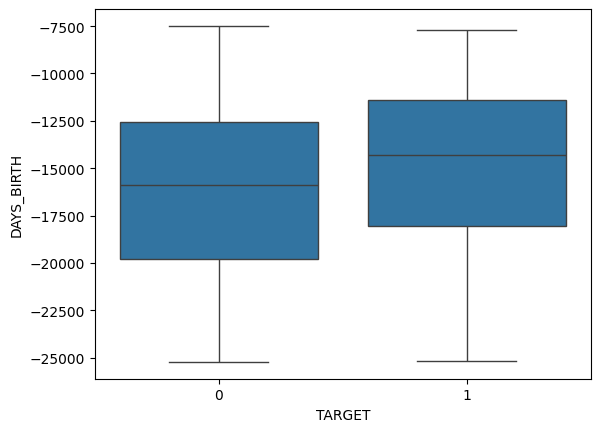

In [14]:
sns.boxplot(x=application_train['TARGET'],y=application_train['DAYS_BIRTH'])

<Axes: xlabel='TARGET', ylabel='REGION_RATING_CLIENT_W_CITY'>

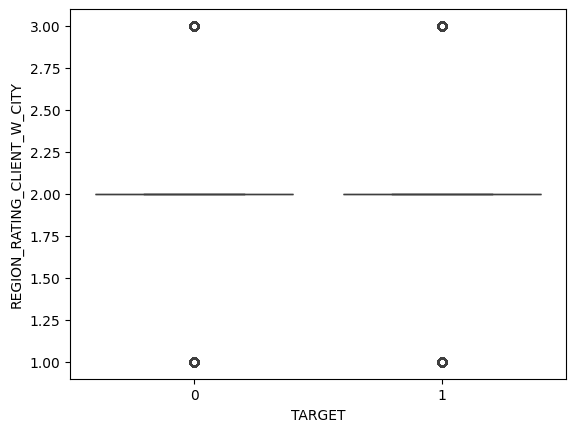

In [15]:
sns.boxplot(x=application_train['TARGET'],y=application_train['REGION_RATING_CLIENT_W_CITY'])

**Checking skewness in attributes**

In [16]:
application_train[num_cols].skew().abs().sort_values(ascending=False).head(10)

,0
FLAG_MOBIL,554.536744
FLAG_DOCUMENT_12,392.114779
AMT_INCOME_TOTAL,391.559654
FLAG_DOCUMENT_10,209.589054
FLAG_DOCUMENT_2,153.791817
AMT_REQ_CREDIT_BUREAU_QRT,134.365776
FLAG_DOCUMENT_4,110.894364
FLAG_DOCUMENT_7,72.174108
FLAG_DOCUMENT_17,61.214140
FLAG_DOCUMENT_21,54.612939


array([[<Axes: title={'center': 'FLAG_MOBIL'}>,
        <Axes: title={'center': 'FLAG_DOCUMENT_12'}>,
        <Axes: title={'center': 'AMT_INCOME_TOTAL'}>],
       [<Axes: title={'center': 'FLAG_DOCUMENT_10'}>,
        <Axes: title={'center': 'FLAG_DOCUMENT_2'}>,
        <Axes: title={'center': 'AMT_REQ_CREDIT_BUREAU_QRT'}>],
       [<Axes: title={'center': 'FLAG_DOCUMENT_4'}>,
        <Axes: title={'center': 'FLAG_DOCUMENT_7'}>,
        <Axes: title={'center': 'FLAG_DOCUMENT_17'}>],
       [<Axes: title={'center': 'FLAG_DOCUMENT_21'}>, <Axes: >, <Axes: >]],
      dtype=object)

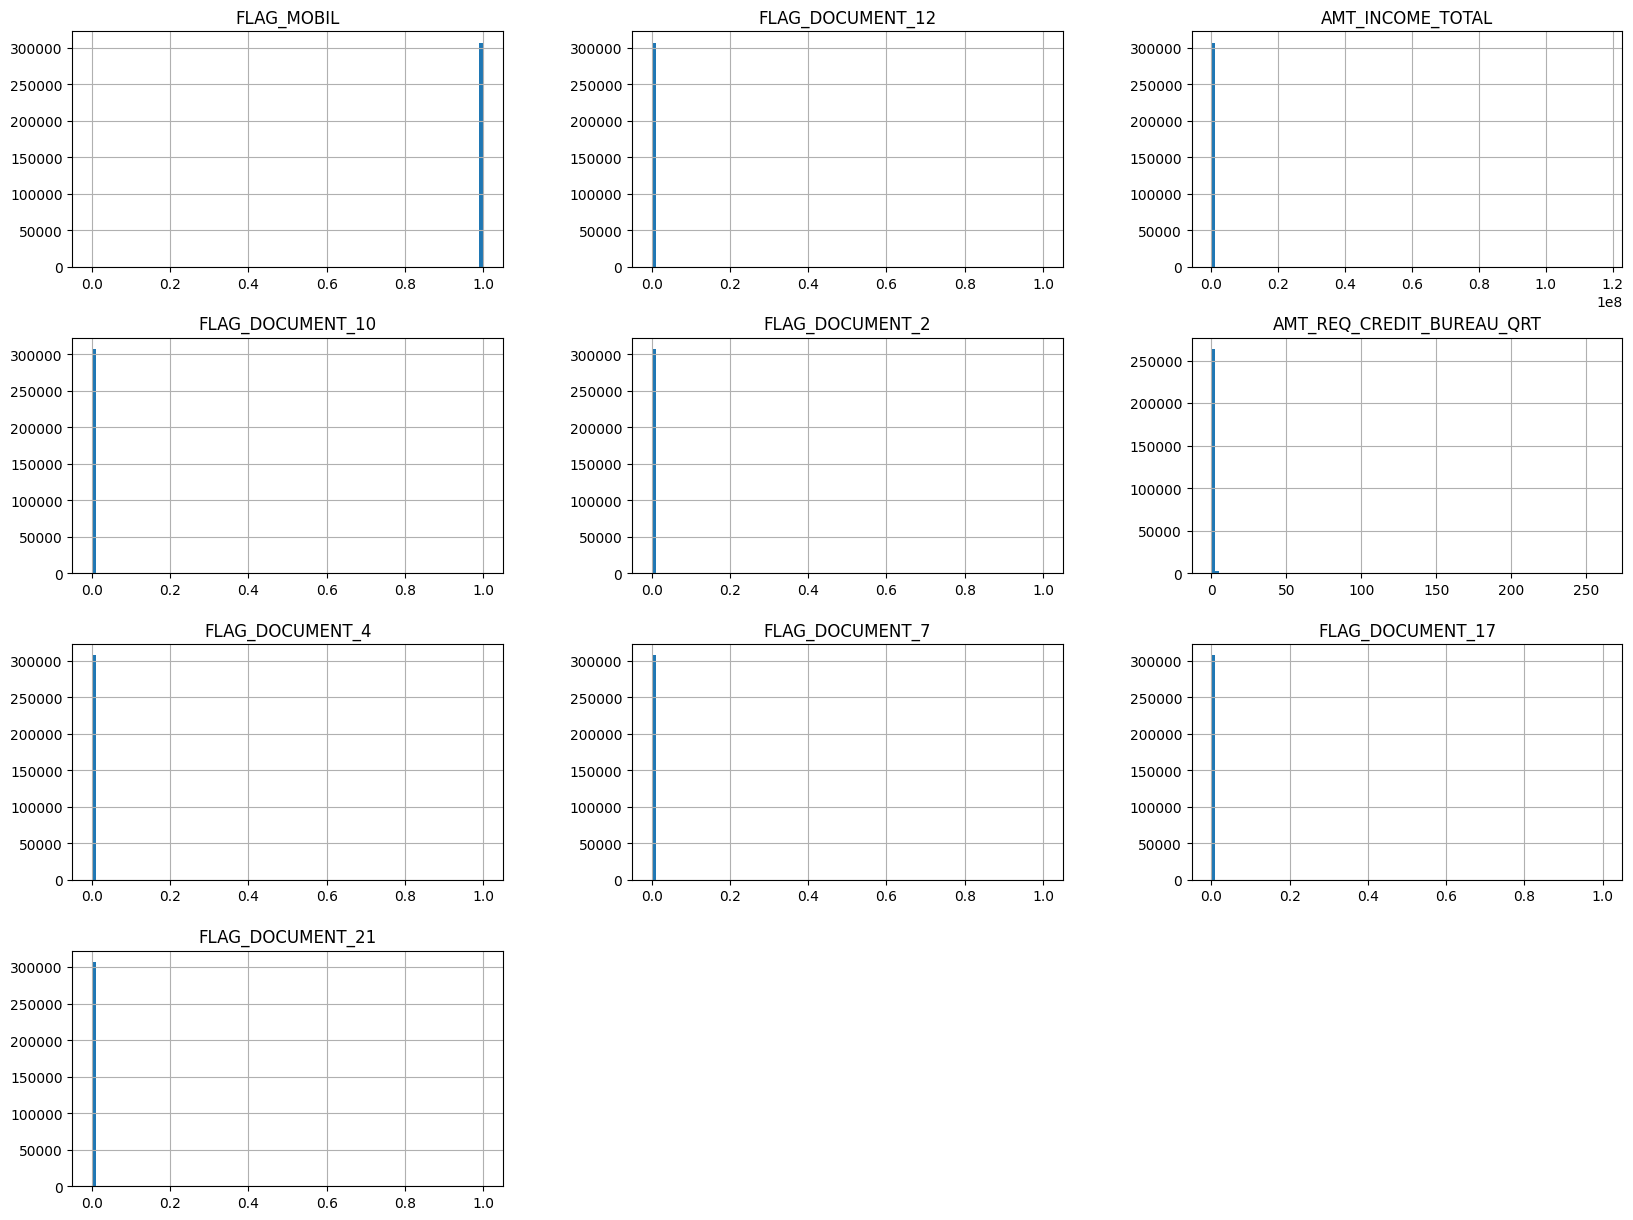

In [17]:
skewed_attributes = ['FLAG_MOBIL','FLAG_DOCUMENT_12','AMT_INCOME_TOTAL','FLAG_DOCUMENT_10','FLAG_DOCUMENT_2','AMT_REQ_CREDIT_BUREAU_QRT','FLAG_DOCUMENT_4','FLAG_DOCUMENT_7','FLAG_DOCUMENT_17','FLAG_DOCUMENT_21']
application_train[skewed_attributes].hist(bins=100,figsize=[20,15])

The top 10 skewed attributes are flags and need to be treated as binary outputs.

Checking skewness for non binary columns

In [18]:
non_binary_cols = [i for i in num_cols if application_train[i].nunique() > 2]

In [19]:
application_train[non_binary_cols].skew().abs().sort_values(ascending=False)

,0
AMT_INCOME_TOTAL,391.559654
AMT_REQ_CREDIT_BUREAU_QRT,134.365776
AMT_REQ_CREDIT_BUREAU_DAY,27.043505
NONLIVINGAPARTMENTS_MODE,16.251819
NONLIVINGAPARTMENTS_MEDI,15.671995
...,...
REGION_RATING_CLIENT,0.087468
EXT_SOURCE_1,0.068755
REGION_RATING_CLIENT_W_CITY,0.059730
HOUR_APPR_PROCESS_START,0.028024


array([[<Axes: title={'center': 'SK_ID_CURR'}>,
        <Axes: title={'center': 'CNT_CHILDREN'}>,
        <Axes: title={'center': 'AMT_INCOME_TOTAL'}>,
        <Axes: title={'center': 'AMT_CREDIT'}>,
        <Axes: title={'center': 'AMT_ANNUITY'}>,
        <Axes: title={'center': 'AMT_GOODS_PRICE'}>,
        <Axes: title={'center': 'REGION_POPULATION_RELATIVE'}>,
        <Axes: title={'center': 'DAYS_BIRTH'}>,
        <Axes: title={'center': 'DAYS_EMPLOYED'}>],
       [<Axes: title={'center': 'DAYS_REGISTRATION'}>,
        <Axes: title={'center': 'DAYS_ID_PUBLISH'}>,
        <Axes: title={'center': 'OWN_CAR_AGE'}>,
        <Axes: title={'center': 'CNT_FAM_MEMBERS'}>,
        <Axes: title={'center': 'REGION_RATING_CLIENT'}>,
        <Axes: title={'center': 'REGION_RATING_CLIENT_W_CITY'}>,
        <Axes: title={'center': 'HOUR_APPR_PROCESS_START'}>,
        <Axes: title={'center': 'EXT_SOURCE_1'}>,
        <Axes: title={'center': 'EXT_SOURCE_2'}>],
       [<Axes: title={'center': 'EXT_SO

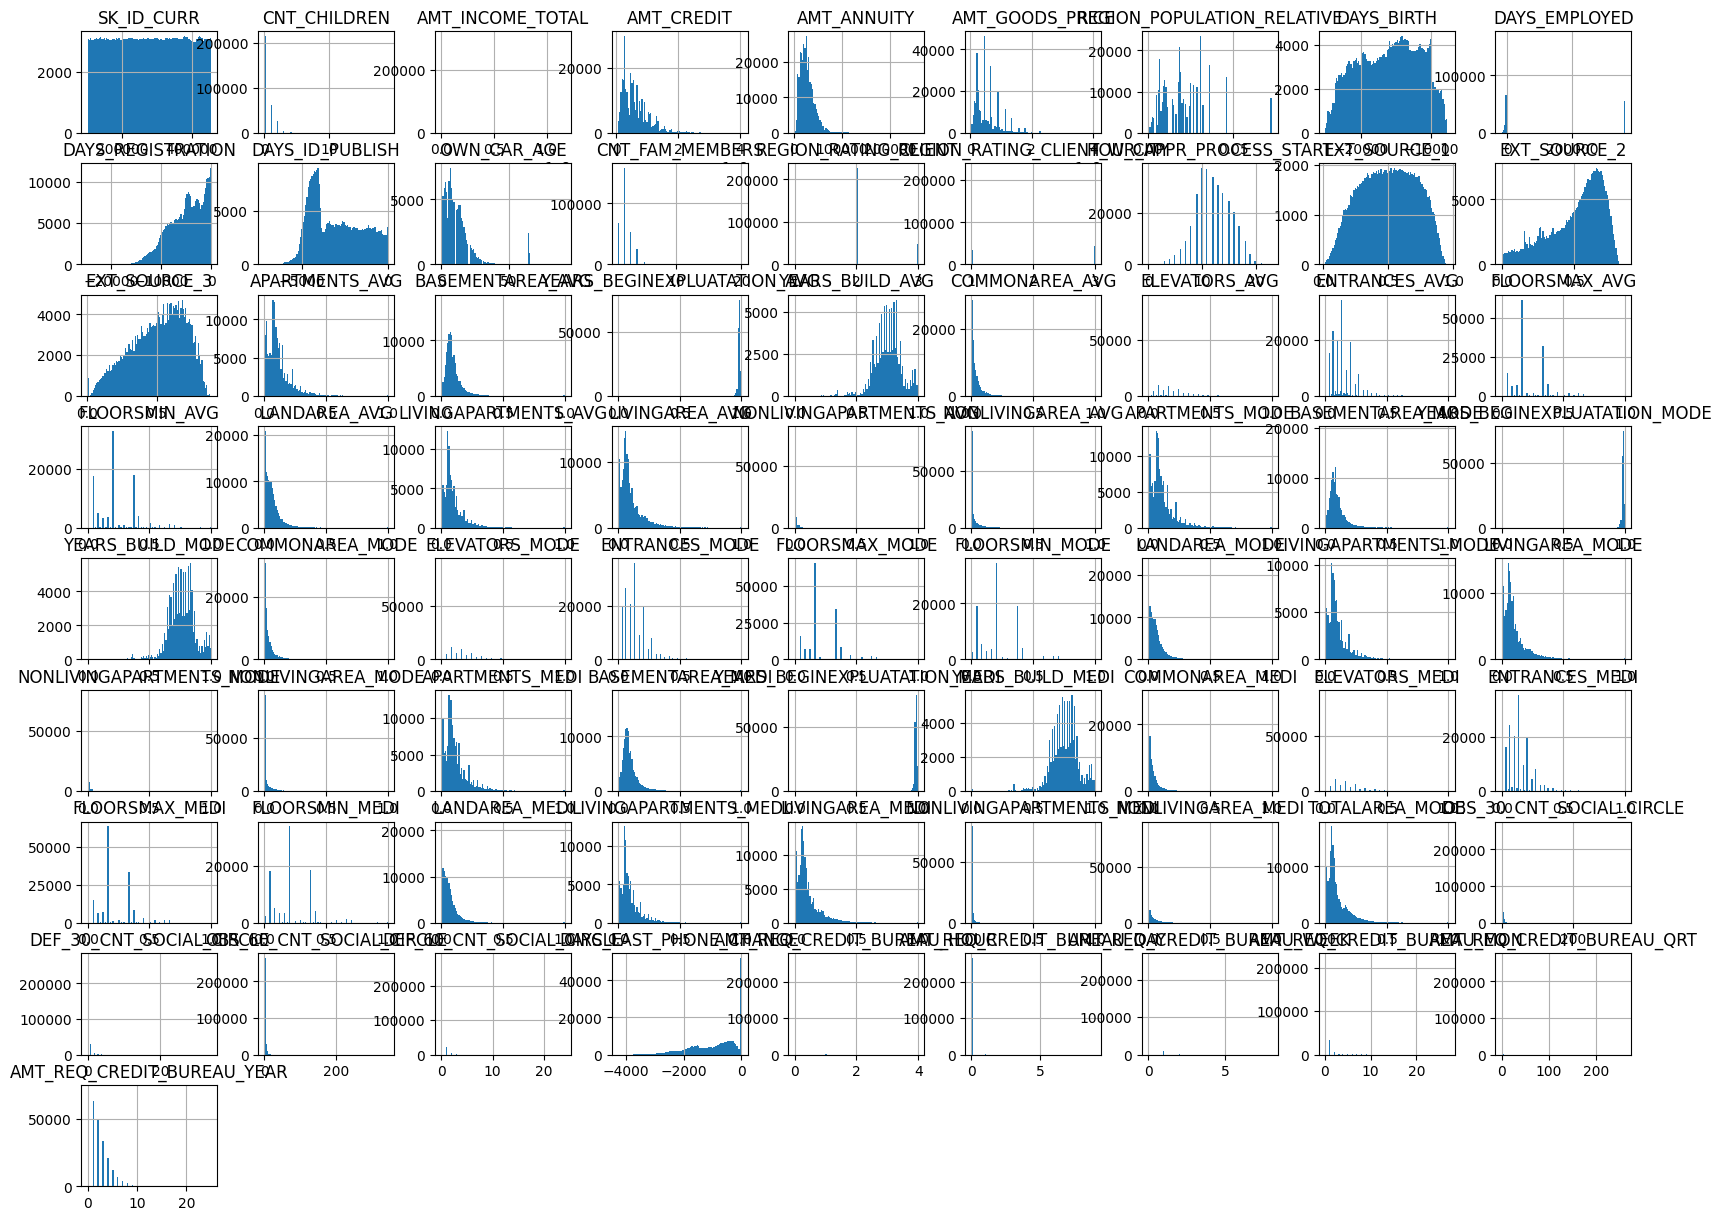

In [20]:
application_train[non_binary_cols].hist(bins=100, figsize=[20,15])

**Checking missing values**

In [21]:
application_train.isnull().mean().sort_values(ascending=False)

,0
COMMONAREA_AVG,0.698723
COMMONAREA_MODE,0.698723
COMMONAREA_MEDI,0.698723
NONLIVINGAPARTMENTS_MEDI,0.694330
NONLIVINGAPARTMENTS_MODE,0.694330
...,...
FLAG_DOCUMENT_16,0.000000
FLAG_DOCUMENT_15,0.000000
FLAG_DOCUMENT_14,0.000000
FLAG_DOCUMENT_20,0.000000
